In [18]:
# Load YOLOv8 model
import torch
from ultralytics import YOLO
model = YOLO("yolov8n.pt")  # You can use 'yolov8s.pt' for a slightly larger model


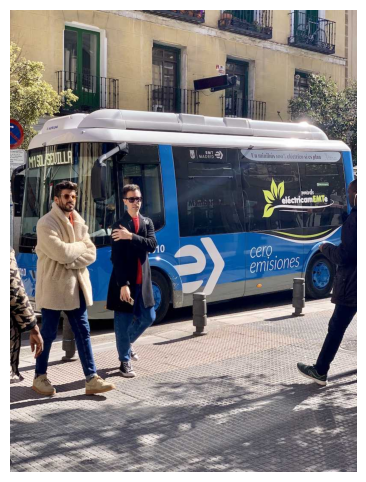

In [19]:
import cv2
import matplotlib.pyplot as plt

image_path = "bus.jpg"  # Change to your actual image file
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct colors

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.show()


In [ ]:
import cv2
import torch
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8n.pt")
!ffmpeg -i DJI_0852.MP4 -vcodec libx264 -crf 28 small_video.mp4

# Load video
video_path = "small_video.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define output video writer
output_path = "output_video1.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # Codec
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Stop when the video ends

    # Run YOLO on frame
    results = model(frame)

    # Convert YOLO results back to an image
    annotated_frame = results[0].plot()

    # Write the processed frame to output video
    out.write(annotated_frame)

cap.release()
out.release()
cv2.destroyAllWindows()

print("✅ Processed video saved as:", output_path)


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [21]:
from IPython.display import Video, display

!ffmpeg -i small_video.mp4 -vf scale=640:360 -crf 28 small_video_resized.mp4


display(Video("output_fixed.mp4", embed=True))



ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [17]:
from IPython.core.display import HTML
HTML('<video width="640" height="360" controls><source src="output_fixed.mp4" type="video/mp4"></video>')
